In [ ]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

#this is the original analysis script as I wrote it, which required printing the datasets throughout the process
#to check that I was processing them correctly, checking abnormalities in naming and formats, fixing errors, etc.
#analysis_script_combined.py is the cleaned up version of this script, which runs all analysis steps without printing anything

In [2]:
my_sheets = [
    "(1) Matrix_Reasoning",
    "(2) Modified_Token_Test_NEW",
    "(2) Modified_Token_Test",
    "(3) Word Definitions",
    "(4) Spelling_Test",
    "(6) Digit_Span",
    "(5) Verbal_Fluency",
    "(7) Language_Production",
    "(9) Recalling_Sentences",
    "(11) N-Back",
]

#index of the column tbat contains the 'score', for each sheet
score_indices=[2,2,3,3,4,None,None,5,8] #process using try: lambda x: try: int(x[score])
# print(len(score_indices))

9

In [20]:
folder_path = Path("scored assessments_dld")

# # Get all .xlsx files
xlsx_files = list(folder_path.glob("*.xlsx"))

# # List to collect processed DataFrames
final_df = pd.DataFrame()

for file_path in xlsx_files:
# Load all sheets from the current Excel file
    sheets = pd.read_excel(file_path, sheet_name=None)  # returns dict {sheet_name: DataFrame}
    sheets = {name: df for name, df in sheets.items() if name in my_sheets}
    if len(sheets)>9: #some of the sheets are named, ordered, or formatted differently
        sheets.pop("(2) Modified_Token_Test", None)
    all_sheets_df = pd.DataFrame()
    for ind, (sheet_name, df) in enumerate(sheets.items()):
        #variables for digit span
        forward = None
        backward = None
        # df = df.dropna(how="all")  # remove empty rows
        # df["source_file"] = file_path.name
        # df["sheet_name"] = sheet_name

        # if there is a 'score' column, try to grab it
        if score_indices[ind] !=None:
            try:
                numeric_vals = pd.to_numeric(df.iloc[:,score_indices[ind]], errors="coerce")
            except Exception as e:
                try:
                    numeric_vals = pd.to_numeric(df.iloc[:,7], errors="coerce") #nback score is one col to the left sometimes :( 
                except Exception as e:
                    print(sheet_name)
                    print(file_path.name)
                    print(df)
            # special cases for nback and digit span tasks
            if sheet_name=='(11) N-Back':
                score_sum = numeric_vals.sum()
            elif sheet_name=='(6) Digit_Span':
                forward = numeric_vals.iloc[18]
                backward = numeric_vals.iloc[-1]
                all_sheets_df=pd.concat([all_sheets_df,pd.DataFrame({'src':file_path.name,'task':['ds_forward'],'score_sum':[forward]}) ])
                all_sheets_df=pd.concat([all_sheets_df,pd.DataFrame({'src':file_path.name,'task':['ds_backward'],'score_sum':[backward]}) ])
                continue
            else:
                score_sum = numeric_vals.iloc[-1]
        else:
            score_sum=None # for verbal fluency and lang production
        # Append to our list
        all_sheets_df=pd.concat([all_sheets_df,pd.DataFrame({'src':file_path.name,'task':[sheet_name],'score_sum':[score_sum]}) ])
    wide_df = all_sheets_df.pivot(index="src", columns="task", values="score_sum")
    wide_df.index.name = None
    wide_df.columns.name = None
    
    final_df = pd.concat([final_df,wide_df])

# Combine all processed data into one DataFrame
# final_df = pd.concat(processed_dfs, ignore_index=True)

# print(final_df.head())

C:\Users\jzp6211\AppData\Local\Temp\ipykernel_30104\3308209877.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_sheets_df=pd.concat([all_sheets_df,pd.DataFrame({'src':file_path.name,'task':[sheet_name],'score_sum':[score_sum]}) ])
C:\Users\jzp6211\AppData\Local\Temp\ipykernel_30104\3308209877.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_sheets_df=pd.concat([all_sheets_df,pd.DataFrame({'src':file_path.name,'task':[sheet_name],'score_sum':[score_sum]}) ])
C:\Users\jzp6211\AppDa

In [21]:
final_df_dld=final_df.copy()

In [91]:
# pd.DataFrame([processed_dfs.score_sum.T],columns=processed_dfs.task.T, index=processed_dfs.src[0])
# wide_df = processed_dfs.pivot(index="src", columns="task", values="score_sum")
# wide_df.index.name = None
# wide_df.columns.name = None

In [17]:
# final_df_td=final_df.copy()

In [23]:
final_df_dld

,(1) Matrix_Reasoning,(11) N-Back,(2) Modified_Token_Test_NEW,(3) Word Definitions,(4) Spelling_Test,(5) Verbal_Fluency,(7) Language_Production,(9) Recalling_Sentences,ds_backward,ds_forward,(2) Modified_Token_Test
561d61b83d7fe800110f5e0a_Assessment.xlsx,23.0,0.0,37.0,42.0,13.0,NaN,NaN,59.0,5.0,10.0,NaN
58adfc6e7cf56d0001f931a2_Assessment.xlsx,20.0,0.0,22.0,28.0,10.0,NaN,NaN,22.0,3.0,0.0,NaN
5d54fef50a2a1600195cb7cf_Assessment.xlsx,17.0,100.0,31.0,39.0,10.0,NaN,NaN,57.0,5.0,10.0,NaN
5dc98ea46c76b36aaada5f47_Assessment.xlsx,21.0,0.0,39.0,0.0,10.0,NaN,NaN,64.0,0.0,0.0,NaN
5edc465dcee6c191209e2d9a_Assessment.xlsx,14.0,67.5,23.0,0.0,7.0,NaN,NaN,36.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Sub67901980b1183615d5c69689_Assessment.xlsx,25.0,75.0,32.0,36.0,11.0,NaN,NaN,67.0,6.0,9.0,NaN
Sub67ac9a33705bcf8912548fca_Assessment.xlsx,17.0,72.5,31.0,19.0,6.0,NaN,NaN,55.0,7.0,8.0,NaN
Sub67acff9270a7fdbb02f3fc29_Assessment.xlsx,22.0,55.0,37.0,23.0,7.0,NaN,NaN,27.0,5.0,10.0,NaN
Sub67ad2e5067f159560e703a56_Assessment.xlsx,20.0,75.0,40.0,29.0,9.0,NaN,NaN,60.0,4.0,6.0,NaN


In [312]:
final_df_td.to_csv('td_summary.csv',index=False)

In [151]:
final_df_dld.to_csv('dld_summary.csv',index=False)

In [24]:
final_df_dld['pop']='dld'
final_df_td['pop']='td'

In [25]:
# final_df_dld.apply(lambda x: x.iloc[2] if x.iloc[2].notna() else x.iloc[-2],axis=1)
final_df_dld['(2) Modified_Token_Test_NEW'] = final_df_dld.iloc[:, 2].fillna(final_df_dld.iloc[:, -2])
final_df_dld.iloc[:, 2].unique()

array([37., 22., 31., 39., 23., 38., 33., 30., 41., nan, 32., 36., 18.,
       24., 35., 28., 21., 16., 25., 27., 17., 29., 20., 26., 19., 40.])

In [26]:
final_df_dld.drop(['(2) Modified_Token_Test'],inplace=True,axis=1)

In [29]:
final_df_dld.isna().sum()

(1) Matrix_Reasoning            1
(11) N-Back                     0
(2) Modified_Token_Test_NEW     1
(3) Word Definitions            1
(4) Spelling_Test               3
(5) Verbal_Fluency             75
(7) Language_Production        75
(9) Recalling_Sentences         2
ds_backward                     4
ds_forward                     11
pop                             0
dtype: int64

In [30]:
final_df=pd.concat([final_df_dld,final_df_td])

In [31]:
final_df['id']= final_df.index

In [32]:
final_df.reset_index(drop=True,inplace=True)
#clean all ids from filenames
final_df['id']=final_df['id'].apply(lambda x: x.split('_Assessment')[0])
final_df['id']=final_df['id'].apply(lambda x: x.split('Sub')[-1])
final_df['id']=final_df['id'].apply(lambda x: x.split('_assessment.xlsx')[0])
final_df['id']=final_df['id'].apply(lambda x: x.split('sub')[-1])
final_df['id']=final_df['id'].apply(lambda x: x.split('_')[-1])
final_df['id']=final_df['id'].apply(lambda x: x.split('Assessment')[0])
final_df['id']=final_df['id'].apply(lambda x: x.split('.xlsx')[0])

In [33]:
demo=pd.read_csv('DLD+lang+screener_August+13,+2025_11.40.csv')

In [34]:
demo =demo[demo.Q18.isin(final_df.id)]

In [35]:
demo.drop_duplicates(subset='Q18',keep='first',inplace=True)

In [36]:
demo=demo.sort_values(by='Q18')

In [37]:
final_df=final_df.sort_values(by='id')

In [38]:
final_df.id

0      561d61b83d7fe800110f5e0a
1      58adfc6e7cf56d0001f931a2
104    5a95a63e4eecca0001dd4cfa
33     5bf21da1f4d94900011ccf32
105    5cfb82036a293c00169ea37e
                 ...           
103    67ec966150bc6430faffe34d
154    67edb23a43cba5516a26a265
155    67f05d8a2b2f772e31167590
156    67f3125c316dfba61f29ff5d
157    67f5828f366e42610fa78fd7
Name: id, Length: 158, dtype: object

In [39]:
demo.Q18

192    561d61b83d7fe800110f5e0a
142    58adfc6e7cf56d0001f931a2
293    5a95a63e4eecca0001dd4cfa
127    5bf21da1f4d94900011ccf32
355    5cfb82036a293c00169ea37e
                 ...           
337    67ec966150bc6430faffe34d
303    67edb23a43cba5516a26a265
330    67f05d8a2b2f772e31167590
305    67f3125c316dfba61f29ff5d
288    67f5828f366e42610fa78fd7
Name: Q18, Length: 158, dtype: object

C:\Users\jzp6211\AppData\Local\anaconda3\envs\csci349\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\jzp6211\AppData\Local\anaconda3\envs\csci349\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\jzp6211\AppData\Local\anaconda3\envs\csci349\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_

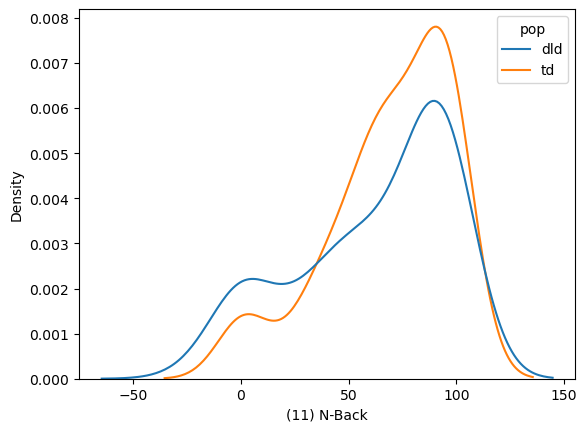

In [366]:
sns.kdeplot(data=final_df, x=final_df.iloc[:,1],hue='pop')
plt.show()

In [171]:
final_df.sort_values(by='(11) N-Back').head(5)

,(1) Matrix_Reasoning,(11) N-Back,(2) Modified_Token_Test_NEW,(3) Word Definitions,(4) Spelling_Test,(5) Verbal_Fluency,(6) Digit_Span,(7) Language_Production,(9) Recalling_Sentences,(2) Modified_Token_Test,pop
6714006452400ecdc5f6b8e6_Assessment.xlsx,21.0,-20.0,35.0,45.0,13.0,NaN,19.0,NaN,53.0,NaN,dld
561d61b83d7fe800110f5e0a_Assessment.xlsx,23.0,0.0,37.0,42.0,13.0,NaN,15.0,NaN,59.0,NaN,dld
58adfc6e7cf56d0001f931a2_Assessment.xlsx,20.0,0.0,22.0,28.0,10.0,NaN,3.0,NaN,22.0,NaN,dld
sub672392ab18be8c6e1e33600c_Assessment.xlsx,18.0,0.0,26.0,34.0,10.0,NaN,18.0,NaN,71.0,NaN,td
5dc98ea46c76b36aaada5f47_Assessment.xlsx,21.0,0.0,39.0,0.0,10.0,NaN,0.0,NaN,64.0,NaN,dld


In [40]:
import ast
import json

In [43]:
csv_folder='scored csvs_td'

# Touch the squares slowly and the circles quickly. - original instructions
# score 1 if squares time is greater than circles time

comparison_df = pd.DataFrame()
for root, dirs, files in os.walk(csv_folder):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            df = pd.read_csv(file_path)

            parsed_data = ast.literal_eval(df.iloc[11].moves)

            tdf = pd.DataFrame(parsed_data)
            score=0
            id=file_path.split('\\')[-1].split('.csv')[0]
            if len(tdf.columns)>0:
                tdf = tdf[['src', 'start', 'end']]
                squares=0
                circles=0
                for _,row in tdf.iterrows():
                    if "circle" in row.src:
                        circles+= row.end - row.start
                    elif "square" in row.src:
                        squares+= row.end - row.start
                if squares>circles:
                    score=1
            comparison_df=pd.concat([comparison_df, pd.DataFrame({'score':score,'id':id}, index=[0])])
            
comparison_df

,score,id
0,0,5a95a63e4eecca0001dd4cfa
0,0,5cfb82036a293c00169ea37e
0,1,5dda154216d10c98f29d411f
0,1,5e0c664d78322543b1fea686
0,1,5e7fefe06c12706d47e35211
...,...,...
0,1,67ec966150bc6430faffe34d
0,1,67edb23a43cba5516a26a265
0,0,67f05d8a2b2f772e31167590
0,0,67f3125c316dfba61f29ff5d


In [44]:
comparison_df_td=comparison_df.copy()
# .score.value_counts()

In [42]:
# comparison_df_dld=comparison_df.copy()

In [45]:
comparison_df_td.score.value_counts()

score
1    67
0    16
Name: count, dtype: int64

In [46]:
comparison_df=pd.concat([comparison_df_td,comparison_df_dld])
comparison_df=comparison_df.sort_values(by='id')

In [47]:
final_df=final_df.sort_values(by='id')

In [48]:
demo=demo.sort_values(by='Q18')

In [49]:
new_scores=[]
for prev_total, addition in zip(final_df.iloc[:,2], comparison_df.score):
    try:
        new_scores.append(prev_total+addition)
    except Exception as e:
        new_scores.append(pd.NA)

In [50]:
final_df.iloc[:,2]=new_scores

In [56]:
final_df.reset_index(drop=True,inplace=True)
demo.reset_index(drop=True,inplace=True)
final_df['age']=demo.Q1
final_df['education']=demo.Q3

In [52]:
final_df.to_csv('full_summary.csv',index=False)

In [58]:
# final_df['age']=demo.Q1.values
print(final_df.education.value_counts())
print(demo.Q3.value_counts())

education
4 year degree            45
Some college             45
High school graduate     37
Professional degree      16
2 year degree            11
Doctorate                 2
Less than high school     1
Name: count, dtype: int64
Q3
4 year degree            45
Some college             45
High school graduate     37
Professional degree      16
2 year degree            11
Doctorate                 2
Less than high school     1
Name: count, dtype: int64


In [463]:
demo.to_csv('filtered_demo.csv',index=False)